In [1]:
import pandas as pd

pheno0 = pd.read_csv("results/Biomarker-Projection-Phenotype-0.csv")
pheno1 = pd.read_csv("results/Biomarker-Projection-Phenotype-1.csv")

In [2]:
# Calculate mortality rate for each phenotype
mortality_pheno0 = pheno0['died_in_hospital'].mean() * 100  # percent
mortality_pheno1 = pheno1['died_in_hospital'].mean() * 100

print(f"Phenotype 0 mortality: {mortality_pheno0:.2f}%")
print(f"Phenotype 1 mortality: {mortality_pheno1:.2f}%")

# Difference
diff = abs(mortality_pheno0 - mortality_pheno1)
print(f"Absolute difference: {diff:.2f}%")


Phenotype 0 mortality: 6.11%
Phenotype 1 mortality: 13.71%
Absolute difference: 7.60%


In [3]:
from scipy.stats import chi2_contingency

# Build contingency table
dead_0 = pheno0['died_in_hospital'].sum()
alive_0 = len(pheno0) - dead_0

dead_1 = pheno1['died_in_hospital'].sum()
alive_1 = len(pheno1) - dead_1

table = [[dead_0, alive_0],
         [dead_1, alive_1]]

chi2, p, dof, expected = chi2_contingency(table)

print(f"Chi-squared test p-value: {p:.4f}")


Chi-squared test p-value: 0.0000


/var/folders/jk/xfmcn4bs6bq9gjrttg7_mg8r0000gn/T/ipykernel_26443/2426917445.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=phenotypes, y=mortality_rates, palette=["#FF6F61", "#4E79A7"], ax=ax)


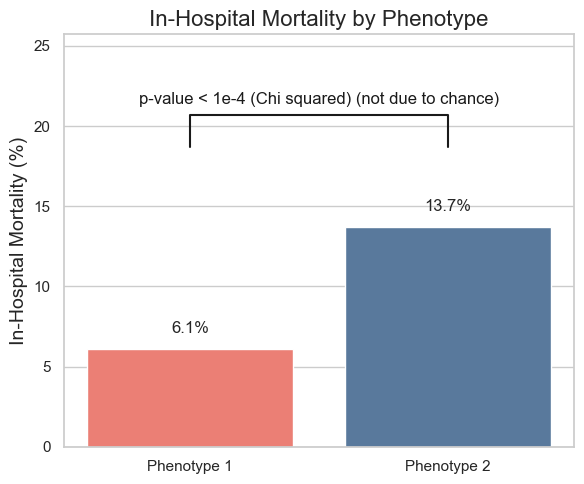

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Mortality percentages you calculated
mortality_pheno0 = pheno0['died_in_hospital'].mean() * 100
mortality_pheno1 = pheno1['died_in_hospital'].mean() * 100

# Prepare data for plotting
phenotypes = ['Phenotype 1', 'Phenotype 2']
mortality_rates = [mortality_pheno0, mortality_pheno1]

# Plot setup
sns.set(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

bars = sns.barplot(x=phenotypes, y=mortality_rates, palette=["#FF6F61", "#4E79A7"], ax=ax)

# Add text labels on top of bars
for bar in bars.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.1f}%', ha='center', fontsize=12)

# Add significance annotation (p < 0.0001)
x1, x2 = 0, 1  # positions of bars
y, h, col = max(mortality_rates) + 5, 2, 'k'

ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c=col)
ax.text((x1+x2)*.5, y+h + 0.5, "p-value < 1e-4 (Chi squared) (not due to chance)", ha='center', va='bottom', color=col, fontsize=12)

# Labels and title
ax.set_ylabel('In-Hospital Mortality (%)', fontsize=14)
ax.set_title('In-Hospital Mortality by Phenotype', fontsize=16)
ax.set_ylim(0, y + h + 5)

plt.tight_layout()
plt.show()
